In [6]:
from langgraph.graph import StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict 
from dotenv import load_dotenv
import os
import time
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")



In [7]:
class crashState(TypedDict):
    input:str
    step1:str
    step2:str
    step3:str
    

In [8]:
def step_1(state : crashState)->crashState:
    print("step one executed")
    return {'step1':'done','input':state['input']}

def step_2(state : crashState)->crashState:
    print("step two  hanging , now manually interrrupt from notebook toolbar by stop button")
    time.sleep(30) # simulate long running hang
    return {'step2':'done'}

def step_3(state : crashState)->crashState:
    print("step three executed")
    return {'step3':'done'}

In [9]:
graph=StateGraph(crashState)

graph.add_node("step1",step_1)
graph.add_node("step2",step_2)
graph.add_node("step3",step_3)

graph.add_edge(START,'step1')
graph.add_edge("step1",'step2')
graph.add_edge("step2",'step3')
graph.add_edge("step3",END)

checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)



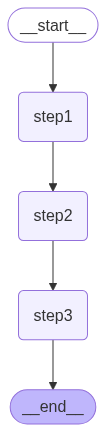

In [10]:
workflow

In [11]:
try:
    print("running graph please manually interrupt during step2")
    workflow.invoke({'input':'start'}, config={'configurable':{'thread_id':'user123'}})

except KeyboardInterrupt:
    print('kernel manually interrupt crash simulated')   



running graph please manually interrupt during step2
step one executed
step two  hanging , now manually interrrupt from notebook toolbar by stop button
kernel manually interrupt crash simulated


In [ ]:
workflow.get_state({'configurable':{'thread_id':'user123'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f0781d6-1910-6e79-8001-a616a58c03f6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-08-13T08:13:23.476626+00:00', parent_config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f0781d6-190d-6a7a-8000-35a107cf4cd5'}}, tasks=(PregelTask(id='77258c1b-c2dc-f1d6-37ef-660bb7bd6e8f', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [13]:
workflow.get_state_history({'configurable':{'thread_id':'user123'}})

<generator object Pregel.get_state_history at 0x0000025A900E9A60>

In [14]:
# re running to show the fault tolerance
final_state=workflow.invoke(None, {'configurable':{'thread_id':'user123'}})
print(final_state)

step two  hanging , now manually interrrupt from notebook toolbar by stop button
step three executed
{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [15]:
workflow.get_state({'configurable':{'thread_id':'user123'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f0781e5-4763-6a2f-8003-8ce7525e97d7'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-08-13T08:20:10.987154+00:00', parent_config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f0781e5-4761-672a-8002-ab9822d9f9e7'}}, tasks=(), interrupts=())

In [16]:
workflow.get_state_history({'configurable':{'thread_id':'user123'}})

<generator object Pregel.get_state_history at 0x0000025A900E9D20>